#### [HOME](../README.md) | [NEXT](2.OOP_Multi_Feature_Linear_Regression.ipynb)

---

# OOP Linear Regression Implementation

This Jupyter Notebook provides a basic implementation of Single Feature Linear Regression. The data set contains measurements on a single species of insect captured on two continents. We want to predict an male insects latitude given the wingspan.

#### Step 1 - Import Dependencies

In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error,mean_squared_error 

#### Step 2 - Import, Filter and Visualise The Data

In [2]:
#Import data as a Pandas DataFrame
insects = pd.read_csv('./data/insects.csv', sep='\t')
insects = pd.DataFrame({
    'continent': insects['continent'],
    'latitude': insects['latitude'],
    'sex': insects['sex'],
    'wingsize': insects['wingsize']
})

# Filter the data to only male insects
insects = insects[insects.sex == 1]

# Features variable
X_insects = insects[['wingsize']]
# Target variable
y_insects = insects['latitude']

insects.head()

,continent,latitude,sex,wingsize
21,1,35.5,1,797
22,1,37.0,1,806
23,1,38.6,1,812
24,1,40.7,1,807
25,1,40.9,1,818


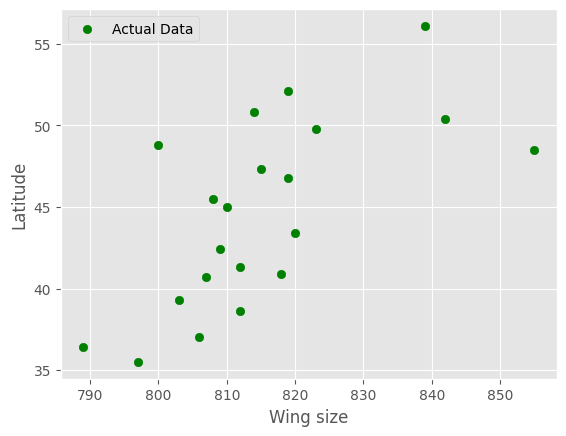

In [3]:
#Plot the data
plt.scatter(X_insects, y_insects, label="Actual Data", color='g')
plt.xlabel("Wing size")
plt.ylabel("Latitude")
plt.legend()
plt.show()

#### Step 3: Instantiate a LinearRegression Object

In [4]:
insects_regression = LinearRegression()

#### Step 4: Fit the model

In [5]:
insects_regression.fit(X_insects, y_insects)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Step 5: Predict Values

In [6]:
# Predict the target for the whole dataset
latitude_predictions = insects_regression.predict(X_insects)

#Predict the target for a new data point
new_insect = pd.DataFrame({
    'wingsize': [800]
})
new_insect['latitude'] = insects_regression.predict(new_insect)
print(f"New insect is:\n{new_insect}")

New insect is:
   wingsize   latitude
0       800  40.870569


#### Step 6: Plot the Predictions

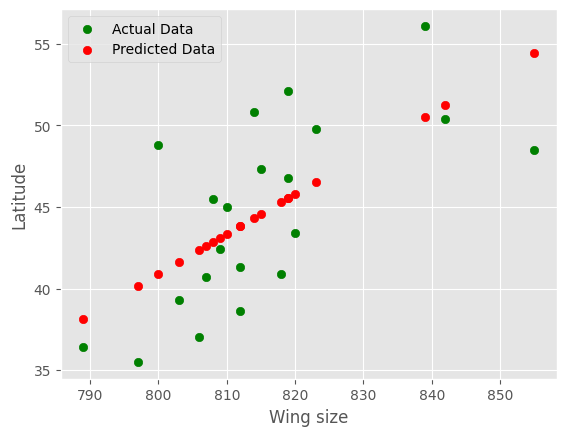

In [7]:
#Plot the predictions compared to the actual data
plt.scatter(X_insects, y_insects, label="Actual Data", color='g')
plt.scatter(X_insects, latitude_predictions, label="Predicted Data", c='r')
plt.xlabel("Wing size")
plt.ylabel("Latitude")
plt.legend()
plt.show()

#### Step 7: Evaluate The Model

In [8]:
#Get Evalutative Data from the model
print(f"Model coefficient :{insects_regression.coef_}")
print(f"Model y intercept :{insects_regression.intercept_}")
print(f"Model score :{insects_regression.score(X_insects,y_insects)}")
mae = mean_absolute_error(y_true=y_insects,y_pred=latitude_predictions) 
mse = mean_squared_error(y_true=y_insects,y_pred=latitude_predictions)
print("MAE:",mae) 
print("MSE:",mse)

Model coefficient :[0.24706008]
Model y intercept :-156.77749557179794
Model score :0.43823454530425576
MAE: 3.6235280772732184
MSE: 17.429174492974532


In [9]:
#Optional: Manually Evaluate the loss and cost of the model
model_loss = pd.DataFrame({
    'Target': y_insects,
    'Predicted result': latitude_predictions,
    'Loss': abs(insects_regression.predict(X_insects).round(2) - y_insects)**2
})
model_cost = 1 / (2 * model_loss.shape[0]) * model_loss['Loss'].sum()

print(f"The cost of this model is {model_cost:.5f}")
print(model_loss)

The cost of this model is 8.71629
    Target  Predicted result     Loss
21    35.5         40.129389  21.4369
22    37.0         42.352930  28.6225
23    38.6         43.835290  27.4576
24    40.7         42.599990   3.6100
25    40.9         45.317651  19.5364
26    42.4         43.094110   0.4761
27    45.0         43.341170   2.7556
28    46.8         45.564711   1.5376
29    48.8         40.870569  62.8849
30    49.8         46.552951  10.5625
31    50.8         44.329410  41.8609
32    36.4         38.152908   3.0625
33    39.3         41.611749   5.3361
34    41.3         43.835290   6.4516
35    43.4         45.811771   5.8081
36    45.5         42.847050   7.0225
37    47.3         44.576470   7.3984
38    48.5         54.458874  35.5216
39    50.4         51.247093   0.7225
40    52.1         45.564711  42.7716
41    56.1         50.505912  31.2481
